In [1]:
!pip install -q git+https://github.com/RayenSansa03/aeroguard.git@main --force-reinstall --no-deps

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [1]:
from google.colab import drive
drive.mount("/content/drive")

import pandas as pd
from aeroguard.donnees_ml import preparer_xy

DOSSIER = "/content/drive/MyDrive/aeroguard"
vols = pd.read_parquet(f"{DOSSIER}/data/processed/vols_ncmapss.parquet")
X_train, y_train = preparer_xy(vols, "train")
X_val, y_val = preparer_xy(vols, "val")

COL_MOTEUR, COL_CYCLE, COL_RUL = "moteur", "cycle", "RUL"
n_moteurs = vols.loc[X_val.index, COL_MOTEUR].nunique()
print("Moteurs en validation :", n_moteurs)
assert n_moteurs == 11, "Il devrait y avoir 11 moteurs en validation !"

Mounted at /content/drive
Moteurs en validation : 11


In [2]:
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from aeroguard.anomalies import alertes, score_anomalie, seuil_percentile

logistique = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(X_train, y_train)
foret = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42).fit(X_train, y_train)
iso = IsolationForest(n_estimators=200, random_state=42).fit(X_train[y_train == 0])
seuil_iso = seuil_percentile(score_anomalie(iso, X_train[y_train == 0]), 90)

alertes_par_modele = {
    "logistique": logistique.predict(X_val),
    "random_forest": foret.predict(X_val),
    "isolation_forest_p90": alertes(score_anomalie(iso, X_val), seuil_iso),
}

In [3]:
from aeroguard.metier import bilan_flotte, resume_flotte

base = vols.loc[X_val.index, [COL_MOTEUR, COL_CYCLE, COL_RUL]].copy()
base["y"] = y_val.values

resultats, bilans = [], {}
for nom, alerte in alertes_par_modele.items():
    for k in [1, 3]:
        table = base.assign(alerte=alerte)
        bilan = bilan_flotte(table, COL_MOTEUR, COL_CYCLE, COL_RUL, k=k)
        bilans[(nom, k)] = bilan
        resultats.append({"modele": nom, "k": k, **resume_flotte(bilan)})

metier = pd.DataFrame(resultats)
metier.round(1)

,modele,k,moteurs,moteurs_detectes,avance_moyenne,avance_mediane,moteurs_avec_fausse_alarme,fausses_alarmes_total
0,logistique,1,11,11,49.5,45.0,9,39
1,logistique,3,11,11,46.1,44.0,4,9
2,random_forest,1,11,11,51.0,54.0,9,73
3,random_forest,3,11,11,48.1,45.0,7,31
4,isolation_forest_p90,1,11,11,42.2,45.0,8,29
5,isolation_forest_p90,3,11,11,24.8,19.0,2,3


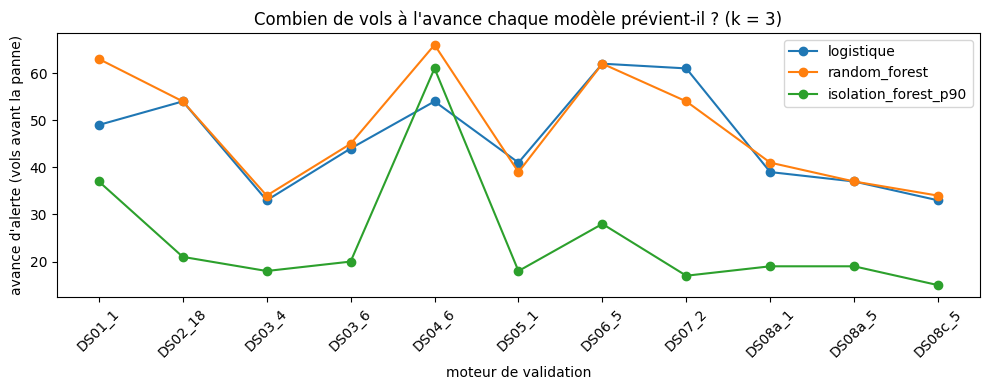

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
for nom in alertes_par_modele:
    b = bilans[(nom, 3)]
    ax.plot(b["moteur"].astype(str), b["avance"], marker="o", label=nom)
ax.set_ylabel("avance d'alerte (vols avant la panne)")
ax.set_xlabel("moteur de validation")
ax.set_title("Combien de vols à l'avance chaque modèle prévient-il ? (k = 3)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
import os

chemin = f"{DOSSIER}/results/leaderboard_metier.csv"
if os.path.exists(chemin):
    os.remove(chemin)
    print("Ancien leaderboard métier supprimé.")

Ancien leaderboard métier supprimé.


In [6]:
from aeroguard.evaluation import ajouter_au_leaderboard

chemin = f"{DOSSIER}/results/leaderboard_metier.csv"
for ligne in resultats:
    nom = f"{ligne['modele']}_k{ligne['k']}"
    scores = {c: ligne[c] for c in ["moteurs_detectes", "avance_moyenne", "avance_mediane",
                                    "moteurs_avec_fausse_alarme", "fausses_alarmes_total"]}
    ajouter_au_leaderboard(chemin, nom, scores)
pd.read_csv(chemin).sort_values("avance_moyenne", ascending=False)

,modele,moteurs_detectes,avance_moyenne,avance_mediane,moteurs_avec_fausse_alarme,fausses_alarmes_total
2,random_forest_k1,11,51.000000,54.0,9,73
0,logistique_k1,11,49.545455,45.0,9,39
3,random_forest_k3,11,48.090909,45.0,7,31
1,logistique_k3,11,46.090909,44.0,4,9
4,isolation_forest_p90_k1,11,42.181818,45.0,8,29
5,isolation_forest_p90_k3,11,24.818182,19.0,2,3
